Import the necessary python library

In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Given values
Provide the following required inputs for the solar collector configuration:
1. Longitude and latitude of your location
2. Tilt angle of the solar collector
3. Surface azimuth angle of the collector
4. Surface reflectivity

In [2]:
#Given values for solar geometry
Longitude = 77.3    #values in degrees
Latitude = 11.03
Tilt = 11 
Surface_azimuth = 0
Reflectivity  = 0.2

#Given values for PTC design
f_trk = 0.99        #Tracking twisting error
f_geo = 0.98        #Geometric accuracy of collector mirror
p_coll = 0.935      #Mirror reflectivity
f_cln = 0.97        #Mirror clealiness
f_dst = 0.98        #Dust losses factor
f_bel = 0.963       #Bellows shadowing factor
f_gls = 0.963       #Glass envelope transmissivity factor
f_abs = 0.96         #Absorber absorption factor
Coll_spac = 10       #Collector spacing
W_coll = 5           #Collector width
L_coll = 50          #Collector Length
U_loss = 0.1         #Solar field heat loss coefficient
F_coll = 1.8        #Collector focal length
T_amb = 35           #Ambient temperature

#Values for outlet temperature of PTC
Specific_heat = 2300    #Specific heat of heat transfer fluid
T_inlet =40            #Heat transfer fluid inlet temperature into solar field 
SM = 2                   #Solar multiple
Calorific_value = 18000000      #Calrofic value in J/kg
Fuel_rate = 2.8    #Fuel consumption in tons/day
Boiler_efficiency = 0.8  #Boiler efficiency
Desired_temp = 240 #Solar field fluid temperture

### **Processing Weather Data to Calculate Solar Declination ( δ)**

imports a weather data file, processes it to convert cumulative hours into days, and calculates the solar declination (δ)) for each day.
\begin{equation}
\delta =23.45\cdot sin[(284+n)\cdot\frac{360}{365}]
\end{equation}

---

### **Import Weather Data and Convert to DataFrame**  
The weather data is imported from a CSV file and converted into a pandas DataFrame for further processing.




In [3]:
weather_data = pd.read_csv('TN weather data.csv') #Importing weather file
df = pd.DataFrame(weather_data)  # Changing the csv into dataframe
# Converting cummulative hour to respective days and creating a new column
df = df.drop('Hour', axis =1)
df.index = range(1, 8761)
Days= []
for i in df.index:
    day = math.ceil(i/24)
    Days.append(day)
df['Days'] = Days
#Calculating delta for all the days
delta= []
for i in df['Days']:
    theta_degree = 360 * (284 + i) / 365
    theta_radian = math.radians(theta_degree)
    de = 23.45 * math.sin(theta_radian)
    delta.append(de)
df['Delta'] = delta   #Creating new column for delta

In [4]:
#For hour angle calculation, individual hours of a day is needed
hours = np.tile(np.arange(1,25), 365)
df['time_slot'] = hours

### **Calculating Hour Angle (ω))**

The following code calculates the **hour angle (ω )** for each time slot in the weather data. The hour angle is essential for determining the position of the sun at a given time and is calculated using the equation of time and local solar time.

---

### **Equation of Time (E)**  

The equation of time (E) corrects the difference between apparent solar time and mean solar time. It is calculated using the following formula:  
\begin{equation}
B = \left( \frac{n - 1}{365} \right) \cdot 360
\end{equation}
\begin{equation}
E = 229.18 \left( 0.000075 + 0.001868 \cos B - 0.032077 \sin B - 0.014615 \cos(2B) - 0.04089 \sin(2B) \right)
\end{equation}
Where:  
- n  = Day of the year  
- B  = Day angle (in degrees)  

---

### **Calculate Local Apparent Time (LAT)**  

The local apparent time is adjusted for the difference between the longitude of the location and the reference longitude (82.5° for IST), as well as the equation of time (E ):  
\begin{equation}
\text{Correction (in minutes)} = 4 \cdot (\text{Longitude} - 82.5) + E
\end{equation}
The local apparent time (LAT) is then:  
\begin{equation}
\text{LAT} = \text{time\_slot}+ \frac{\text{Correction}}{60} - 0.5
\end{equation}
*Note: The subtraction of 0.5 accounts for the fact that the data represents the average value at 30 minutes between each hour.*

---

### **Calculate Hour Angle (ω)**  

The hour angle (ω) is given by:  
\begin{equation}
\omega = (\text{LAT} - 12) \cdot 15
\end{equation}
Where ω is in degrees.





In [5]:
#Calculating hour angle
Hour_angle = []
for i,j in zip(df['Days'], df['time_slot']):
    B_degree = (i -1) * 360 / 365
    B = math.radians(B_degree)
    E = 229.18 * (0.000075 + 0.001868 * math.cos(B) - 0.032077*math.sin(B) - 0.014615* math.cos(2*B) - 0.04089* math.sin(2*B))
    mins = 4 * (Longitude - 82.5) + E
    LAT = j + (mins/60) - 0.5 #Data is for average at 30 mins in between hours, so minus 0.5 hours
    hour_angle = (LAT-12) * 15
    Hour_angle.append(hour_angle)
df['Hour_angle'] = Hour_angle # Creating new column for hour angle

### **Calculating Incident Angle (θ$_i$) and Zenith Angle ( θ$_z$)**

To calculates the **cosine of the solar incident angle (cos(θ$_i$))** and **cosine of the solar zenith angle (cosθ$_z$)** for each time step using the following parameters:  

- β: Surface tilt angle (in radians)  
- γ: Surface azimuth angle (in radians)  
- ϕ: Latitude (in radians)  
- δ: Solar declination angle (in radians)  
- ω: Hour angle (in radians)  

---

1. Convert angles from degrees to radians:  
\begin{equation}
\delta = \text{radians}(\Delta), \quad \omega = \text{radians}(\text{Hour Angle}), \quad \beta = \text{radians}(\text{Tilt}), \quad \gamma = \text{radians}(\text{Surface Azimuth})
\end{equation}

2. Intermediate calculations:  

\begin{equation}
A = \cos\delta \cdot \cos\omega \cdot \sin\phi - \sin\delta \cdot \cos\phi
\end{equation}
\begin{equation}
B = \sin\beta \cdot \sin\gamma \cdot \cos\delta \cdot \sin\omega
\\
C = cos\delta \cdot \cos\omega \cdot \cos\phi + \sin\delta \cdot \sin\phi
\end{equation}

3. The cosine of the incident angle (cosθ$_i$) is given by:  
\begin{equation}
\cos\theta_i = \sin\beta \cdot \cos\gamma \cdot A + B + \cos\beta \cdot C
\end{equation}

4. The cosine of the zenith angle (cosθ$_z$) is simply:  
\begin{equation}
\cos\theta_z = C
\end{equation}

### **Final Output**
These calculations are necessary for determining the solar irradiance on a tilted surface using models such as the HDKR model.


In [6]:
#Calculating incident angle and zenith angle
Cos_theta = []
Cos_theta_z = []
beta = math.radians(Tilt)
gamma = math.radians(Surface_azimuth)
pi = math.radians(Latitude)
for i,j in zip(df['Delta'], df['Hour_angle']):
    #Formulas        i = delta, j = hour_angle
    delta = math.radians(i) #Changing degree into radians because math library takes radian value as default
    omega = math.radians(j)
    A = (math.cos(delta) * math.cos(omega) * math.sin(pi)) - (math.sin(delta)* math.cos(pi))
    B = math.sin(beta) *math.sin(gamma)* math.cos(delta)* math.sin(omega)
    C = (math.cos(delta) * math.cos(omega) * math.cos(pi)) + (math.sin(delta) * math.sin(pi))
    CTheta = (math.sin(beta)*math.cos(gamma)*A) + B + (math.cos(beta)*C)
    CTheta_Z = C
    Cos_theta.append(CTheta)
    Cos_theta_z.append(CTheta_Z)

df['Cos_theta'] = Cos_theta  #Creating new column
df['Cos_theta_z'] = Cos_theta_z #Creating new column

### **Finding \( I$_b$ \) and \( I$_d$ \) from Available Data**

This code determines the beam irradiance  (***I$_b$***) and diffuse irradiance **( I$_d$)** from the available columns in the dataset. The available data can be:  
1. Global Horizontal Irradiance (GHI) and Diffuse Horizontal Irradiance (DHI)  
2. Diffuse Horizontal Irradiance (DHI) and Beam Normal Irradiance (BNI)  
3. Global Horizontal Irradiance (GHI) and Beam Normal Irradiance (BNI)  

---

#### **Case 1: When GHI and DHI are Available**  
\begin{equation}
I_b = \text{GHI} - \text{DHI}
\end{equation}  

#### **Case 2: When DHI and DNI are Available**  
\begin{equation}
I_b = \text{DNI} \cdot \cos\theta_z
\end{equation}
Where θ$_z$ is the solar zenith angle.  

#### **Case 3: When GHI and DNI are Available**  
\begin{equation}
I_b = \text{DNI} \cdot \cos\theta_z
\\  
I_d = \text{GHI} - I_b
\end{equation}

In [7]:
# Finding Ib and Id
Column_names = list(df.columns)
Combo1 = ['GHI', 'DHI']        #GHI - Global horizontal irradiance
Combo2 = ['DHI', 'DNI']        #DHI - Diffuse horizontal irradiance
Combo3 = ['GHI', 'DNI']        #DNI - Direct normal irradiance
Ib = []
if set(Combo1).issubset(Column_names):  #Checking which two values are available and findig Ib and Id
    print('yes1')
    for i, j in zip(df['GHI'], df['DHI']):
        ib = i - j
        Ib.append(ib)

elif set(Combo2).issubset(Column_names):
    print('yes2')
    for i,j in zip(df['BNI'], df['Cos_theta_z']):
        ib = i * j
        Ib.append(ib)

elif set(Combo3).issubset(Column_names):
    print('yes3')
    I_diffuse = []
    for i, j, k in zip(df['GHI'], df['BNI'], df['Cos_theta_z']):
        ib = j * k
        idiffuse = i - ib
        IB.append(ib)
        I_diffuse.append(idiffuse)
    df['DHI'] = I_diffuse
df['IB'] = Ib

yes1


### Liu-Jordan model.

The **Liu-Jordan formula** is used to calculate the tolal radiation I$_t$ on a tilted surface:  

\begin{equation}
I_t = I_b r_b+ I_d r_d + (I_b + I _d) r_r
\end{equation}

Where:  

\begin{equation}
r_b = \frac{\cos\theta_i}{\cos\theta_z}, \quad r_d = \frac{1 + \cos\beta}{2}, \quad r_r = \rho \cdot \frac{1 - \cos\beta}{2}
\end{equation}

-  I$_t$ = Total irradiance on the tilted surface  
- I$_b$ = Beam normal irradiance (DNI)  
- I$_d$ = Diffuse horizontal irradiance (DHI)  
- β = Tilt angle of the surface  
-  θ$_i$= Incidence angle on the tilted surface  
- θ$_z$ = Zenith angle  
-  ρ= Surface reflectivity (albedo)  

This formula assumes isotropic sky conditions and distributes diffuse radiation uniformly across the hemisphere.


In [8]:
#Liu and Jordan model
i = df['Cos_theta'].to_numpy()   #Cos_theta
j = df['Cos_theta_z'].to_numpy()  #Cos_theta_z
k = df['IB'].to_numpy()           #Ib
l= df['DHI'].to_numpy()           #Id
cos_beta = math.cos(math.radians(Tilt))
rb = i/j                                  #beam_reflectivity
rd = (1 + cos_beta) / 2                 #Diffuse_reflectivity
rr = Reflectivity * (1 - cos_beta) / 2  #Radiation_reflectivity
It_liu = (k * rb) + (l * rd) + ((k + l) * rr) #Intensity_tilted
It_liu = It_liu.tolist()
df['It_Liu_jordan'] = It_liu

In [9]:
maximum = df['It_Liu_jordan'].max()
minimum = df['It_Liu_jordan'].min()
print(f'(maximum intensity and minimum intensity):{maximum}, {minimum}')

(maximum intensity and minimum intensity):1086.1973960265805, 0.0


### **HDKR Model for Total Irradiance on a Tilted Surface**

The total irradiance on a tilted surface using the **HDKR (Hay-Davies-Klucher-Reindl) model is calculated as:  
\begin{equation}
I_t = I_b  r_b + I_d F r_d + I_d (\frac{1 - \cos\beta} 2) + (I_b + I_d) r_r
\end{equation}

Where:  

\begin{equation}
r_b = \frac{\cos\theta_i}{\cos\theta_z}, \quad r_d = \frac{1 + \cos\beta}{2}, \quad r_r = \rho \cdot \frac{1 - \cos\beta}{2}
\end{equation}

-  I$_t$ = Total irradiance on the tilted surface  
- I$_b$ = Beam normal irradiance (DNI)  
- I$_d$ = Diffuse horizontal irradiance (DHI)  
- β = Tilt angle of the surface  
-  θ$_i$= Incidence angle on the tilted surface  
- θ$_z$ = Zenith angle  
-  ρ= Surface reflectivity (albedo)  

---

### **Anisotropic Index (\(F\))**

\begin{equation}
F = 1 + f \cdot \left( \frac{I_b}{I_b + I_d} \right) \cdot \sin^3\left(\frac{\beta}{2}\right)
\end{equation}

Where:  
- f = 0.5  (empirical constant for anisotropic index)  
-  β = Surface tilt angle in degrees  

---


In [10]:
#HDKR model
f = 0.5 # empirical anisotropic index value
cos_beta = math.cos(math.radians(Tilt))
sine = math.sin(math.radians(0.5*Tilt)) # for calculation of F (Anisotropic Index)
sine_cube = pow(sine, 3)
rd = (1 + cos_beta) / 2                 #Diffuse_reflectivity
rr = Reflectivity * (1 - cos_beta) / 2  #Radiation_reflectivity
Intensity_tilted_HDKR = []
for i,j,k,l in zip(df['Cos_theta'], df['Cos_theta_z'], df['IB'], df['DHI']):
    rb = i / j                              #Beam_reflectivity
    if (k+l) > 0:
        F = 1 + (f* (k/(k+l)) * sine_cube)         # Anisotropic Index
        It = (k * rb) + (l * rd * F) + (l * 0.5 * (1-cos_beta)) + ((k + l) * rr) #Intensity_tilted
        Intensity_tilted_HDKR.append(It)
    else:
        It = 0
        Intensity_tilted_HDKR.append(It)
df['It_HDKR'] = Intensity_tilted_HDKR

In [11]:
maximum = df['It_HDKR'].max()
minimum = df['It_HDKR'].min()
print(f'(maximum intensity and minimum intensity):{maximum}, {minimum}')

(maximum intensity and minimum intensity):1087.431978329402, 0.0


### Save image function

In [12]:
import os
Image_path = os.path.join('.', 'Images')
os.makedirs(Image_path, exist_ok = True)
def save_fig(image):
    path = os.path.join(Image_path, image+'.'+'png')
    plt.tight_layout()
    plt.savefig(path, format= 'png', dpi = 300)

### DNI Analysis - Range and frequency

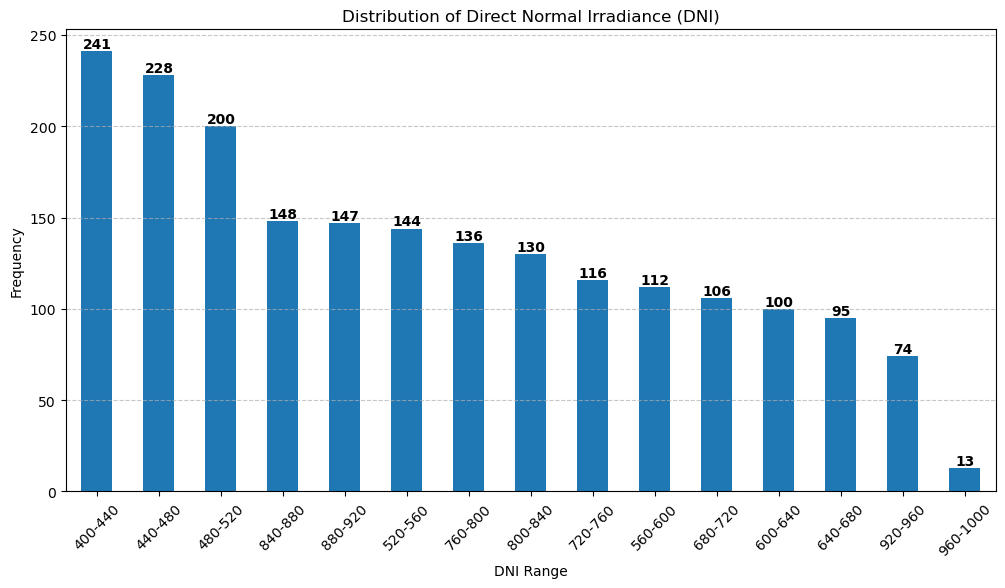

In [13]:
# Function to create bins
def label_dni(value):
    if value < 400:
        return "Below 400"
    else:
        bin_start = (value // 40) * 40
        bin_end = bin_start + 40 
        return f"{bin_start}-{bin_end}"

df['DNI_Label'] = df['DNI'].apply(label_dni)
label_counts = df['DNI_Label'].value_counts()
label_counts = label_counts[label_counts.index != 'Below 400']

# Plot the histogram
plt.figure(figsize=(12, 6))
bars = label_counts.plot(kind='bar')
plt.xlabel('DNI Range')
plt.ylabel('Frequency')
plt.title('Distribution of Direct Normal Irradiance (DNI)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, 
             bar.get_height(),                   
    f'{int(bar.get_height())}',        
    ha='center', va='bottom', fontsize=10, fontweight='bold')
#save_fig('Distribution of Direct Normal Irradiance')
plt.show() 

### Days and solar irradiance frequency DNI analysis 

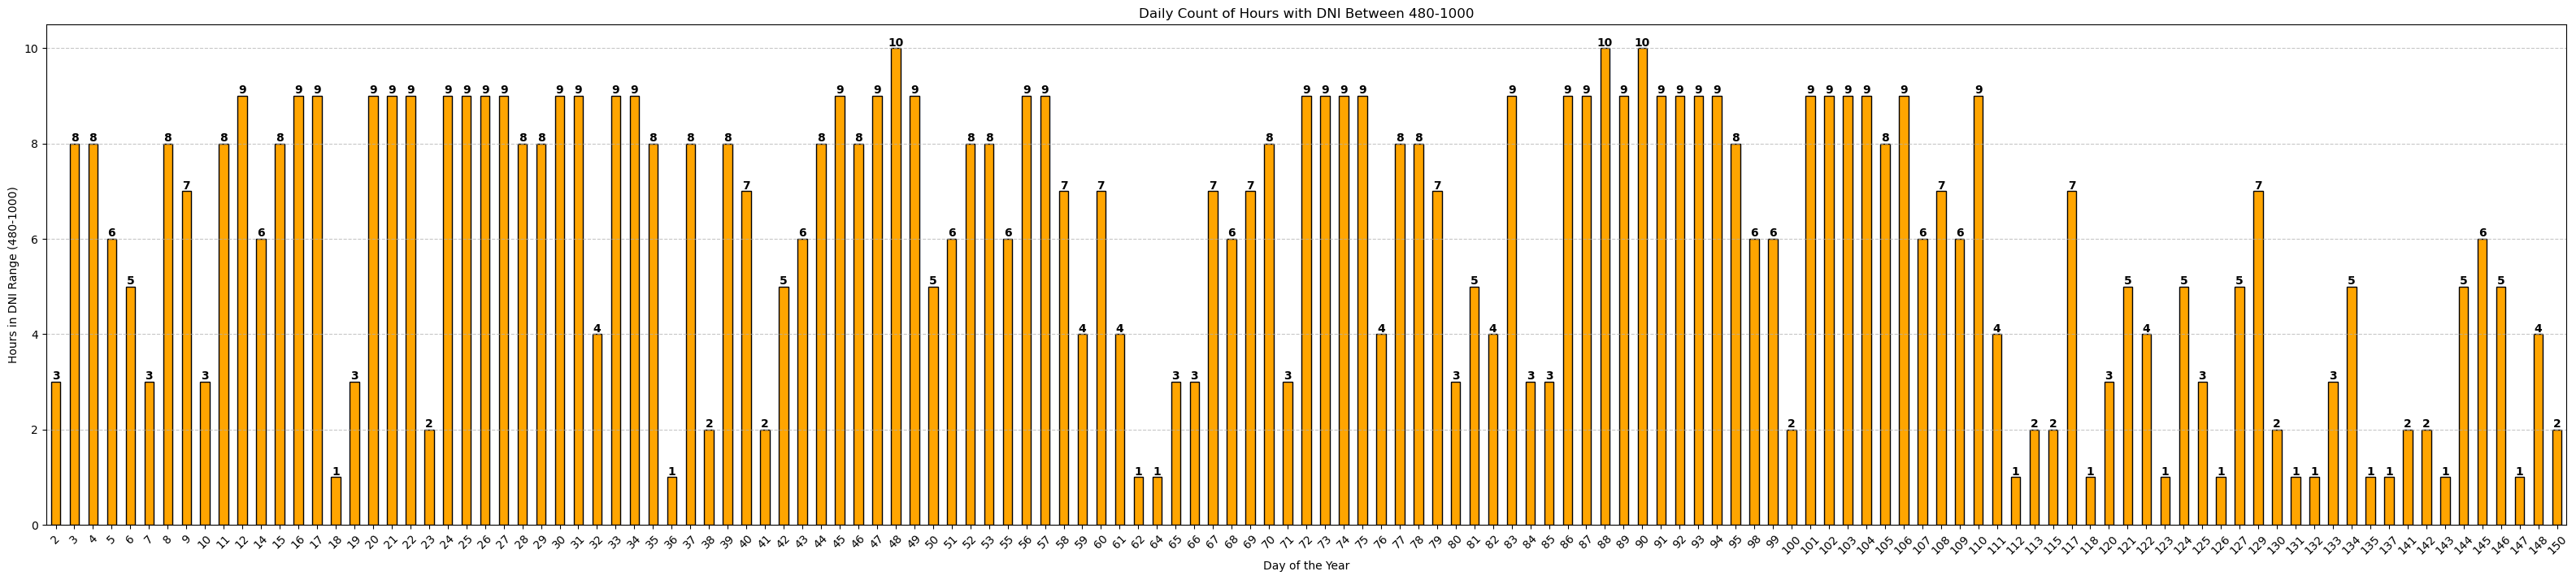

No of days DNI above 550 W/m^2: 135


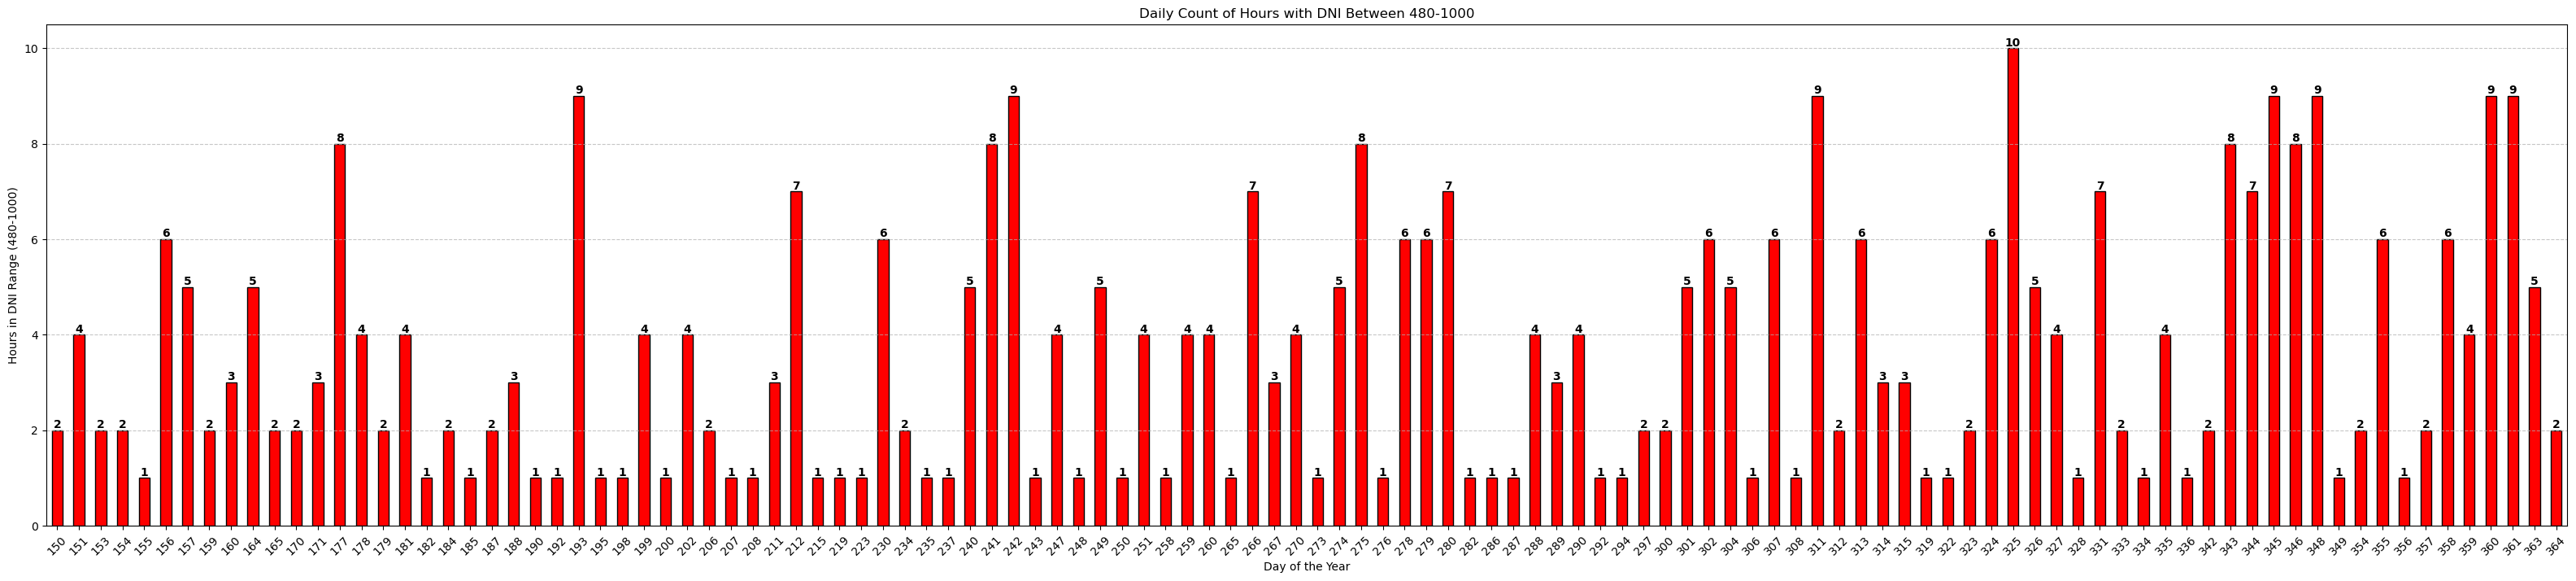

No of days DNI above 550 W/m^2: 116


In [14]:
def DNI_graph(Start_date, End_date, graph_color, image_name):
    days = df['Days'] 
    df_filtered = df[(df['DNI'] >= 550) & (df['Days'] >=Start_date) & (df['Days'] <=End_date)]
    daily_counts = df_filtered.groupby('Days').size()
    plt.figure(figsize=(40, 8))
    bar = daily_counts.plot(kind='bar', color=graph_color, edgecolor='black')
    plt.xlabel('Day of the Year')
    plt.ylabel('Hours in DNI Range (480-1000)')
    plt.title('Daily Count of Hours with DNI Between 480-1000')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    for bar in bar.patches:
        plt.text(bar.get_x() + bar.get_width() / 2, 
                 bar.get_height(), 
                 f'{int(bar.get_height())}', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    #save_fig(image_name)
    plt.show()
    print(f'No of days DNI above 550 W/m^2: {len(daily_counts)}')
DNI_graph(1,150,'Orange', 'Image1')
DNI_graph(150, 365, 'Red', 'Image2')

### **PTC Design**

In [15]:
#PTC design
#Finding Cos_theta for area collector formula
j = df.loc[4116, 'Cos_theta_z']
k = df.loc[4116,'Delta']
l = df.loc[4116, 'Hour_angle']
j_square = j ** 2
cos_delta_square = (np.cos(np.radians(k)))** 2  #(Cos_delta)^2
sin_omega_square = (np.sin(np.radians(l))) **2  #(Sin_omega)^2
C_theta = np.sqrt(j_square+cos_delta_square*sin_omega_square) #Cos_theta
theta = np.degrees(np.arccos(C_theta))    #theta
tan_theta = np.tan(np.arccos(C_theta))#tan_theta

#Finding Incidence angle modifier
IAM = 1 + ((8.84*theta)/(10000*C_theta)) - ((5.369*theta*theta)/(100000*C_theta))

#PTC solar field efficiency
E_collector = f_trk * f_geo * p_coll * f_cln
E_reciever = f_dst * f_bel * f_gls * f_abs
E_shadow = Coll_spac * j / (W_coll * C_theta)
End_loss_factor = 1 - (F_coll*tan_theta/L_coll) 
E_solar_field = E_collector * E_reciever * E_shadow * End_loss_factor
E_solar_field = round(E_solar_field,4)

### Required Heat input and mass flow rate of the heat transfer liquid

In [16]:
Q_design_input = round(Fuel_rate*1000*Calorific_value* Boiler_efficiency/(12*60*60)) #Heat input to the stenter in Watts
HM_massflowrate = round(Q_design_input/(Specific_heat*(Desired_temp-T_inlet)),2) #Mass flow rate of fluid
print(f'Q_design_input: {Q_design_input}, HM_massflowrate:{HM_massflowrate}')

Q_design_input: 933333, HM_massflowrate:2.03


### Collector area calculation for differnet solar irradiance

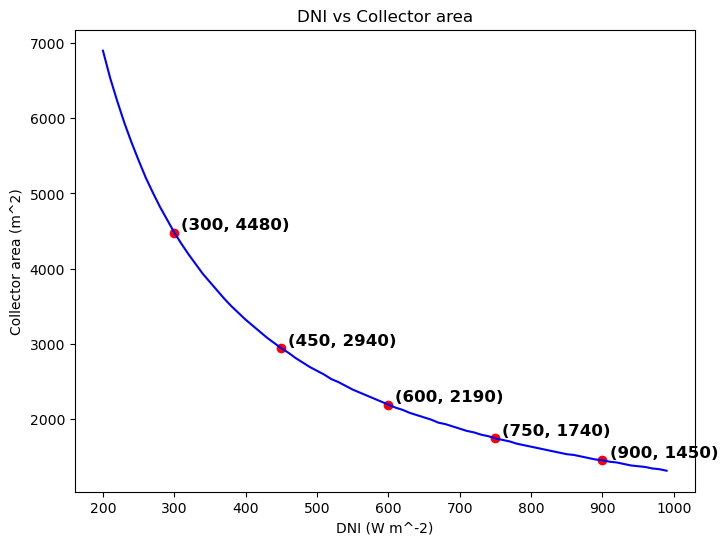

In [17]:
#Collector area
Q_SF = SM * Q_design_input #Heat output from solar field
DNI_values=[]
A_collector = []   
for i in range(200,1000,10):
    DNI = i
    Denominator = DNI*C_theta*E_solar_field*IAM - (U_loss*(Desired_temp - T_amb))
    A_coll = round(Q_SF / (Denominator*10))*10
    DNI_values.append(i)
    A_collector.append(A_coll)
plt.figure(figsize=(8,6))
graph=plt.plot(DNI_values, A_collector, color = 'Blue')
plt.xlabel('DNI (W m^-2)')
plt.ylabel('Collector area (m^2)')
plt.title('DNI vs Collector area')
for i in range(10,len(A_collector),15):
    plt.scatter(DNI_values[i],A_collector[i], color='red')
    plt.text(DNI_values[i]+10,A_collector[i]+200, 
                 f'{DNI_values[i], A_collector[i]}', 
                 fontsize=12, va='top', ha='left', fontweight='bold')
#save_fig('DNI vs Collector area')
plt.show()

### **Outlet fluid temperature from PTC**

In [18]:
def outlet_fluid_temperature(A_coll):
    E_collector = f_trk * f_geo * p_coll * f_cln  #Input values
    E_reciever = f_dst * f_bel * f_gls * f_abs
    T_fluid_outlet = []
    for j,k,l,m in zip(df['Cos_theta_z'],df['Delta'], df['Hour_angle'],df['DNI']):
        j_square = j ** 2
        cos_delta_square = (np.cos(np.radians(k)))** 2  #(Cos_delta)^2
        sin_omega_square = (np.sin(np.radians(l))) **2  #(Sin_omega)^2
        C_theta = np.sqrt(j_square+cos_delta_square*sin_omega_square) #Cos_theta
        theta = np.degrees(np.arccos(C_theta))    #theta
        tan_theta = np.tan(np.arccos(C_theta))#tan_theta

    #Finding Incidence angle modifier for different time and  DNI
        IAM = 1 + ((8.84*theta)/(10000*C_theta)) - ((5.369*theta*theta)/(100000*C_theta))
        E_shadow = Coll_spac * j / (W_coll * C_theta)
        End_loss_factor = 1 - (F_coll*tan_theta/L_coll) 
        E_solar_field = E_collector * E_reciever * E_shadow * End_loss_factor
        E_solar_field = round(E_solar_field,4)

        #Temperature outlet from the field
        if m > 0:    #DNI greater than zero, then only outlet from PTC is possible
            Constant = m*C_theta*E_solar_field*IAM
            Numerator = A_coll*(Constant+U_loss*T_amb) + (HM_massflowrate*Specific_heat*T_inlet)
            Denominator = (HM_massflowrate*Specific_heat) + (A_coll*U_loss)
            T_fo = round(Numerator/Denominator,1)
            T_fluid_outlet.append(T_fo)

        else:
            T_fo = T_inlet
            T_fluid_outlet.append(T_fo)
    df['PTC Tfo'] = T_fluid_outlet #Adding new column for PTC outlet temperarture

### Fuel saved calculation

In [19]:
def fuel_calculation(Q_design_input):
    global Calorific_value, Boiler_efficiency
    m = (Q_design_input/(Calorific_value*Boiler_efficiency))*3600 #one hour required wood in ton
    return m

def pre_heating_fuel_calculation(Q_design_input,T_fo):
    global HM_massflowrate, Specific_heat, Desired_temp, Boiler_efficiency, Calorific_value
    Output = HM_massflowrate*Specific_heat*(Desired_temp - T_fo)   
    m = (Output/ (Calorific_value * Boiler_efficiency)) * 3600 #Wood required after prehaeting to achieve desired temp.
    Actual_fuel_required = (Q_design_input/(Calorific_value*Boiler_efficiency))*3600 #wood required for 1 hour without PTC
    saved_fuel = Actual_fuel_required - m #Saved fuel after heating the preheating oil
    return saved_fuel

### Thermal storage integration

In [20]:
def thermal_storage_integration():
    Fuel_used = []
    Storage_state = 'Empty'
    for i,j,k in zip(df['time_slot'], df['PTC Tfo'], df['Days']):
        if 9<= i<= 21:
            if j >= Desired_temp and Storage_state == 'Empty': #Empty storage and temp stored is >= 240
                Storage_state = 'Charged'
            elif j>= Desired_temp and Storage_state == 'Charged':
                a = fuel_calculation(Q_design_input) #Fuel calculation to find how much reduction happened
                Fuel_used.append(a)
            elif j< Desired_temp and Storage_state == 'Charged':
                Storage_state = 'Empty'
            elif j< Desired_temp and Storage_state == 'Empty': #Pre heating the oil when the temp. is less than desired
                a = pre_heating_fuel_calculation(Q_design_input,j)
                Fuel_used.append(a)
    return round(sum(Fuel_used)/1000)

### Fuel saved calcuation for different collector area 

In [21]:
Fuel_saved_for_different_area = []
for i in A_collector:
    outlet_fluid_temperature(i)
    Fuel_saved = thermal_storage_integration()
    Fuel_saved_for_different_area.append(Fuel_saved)

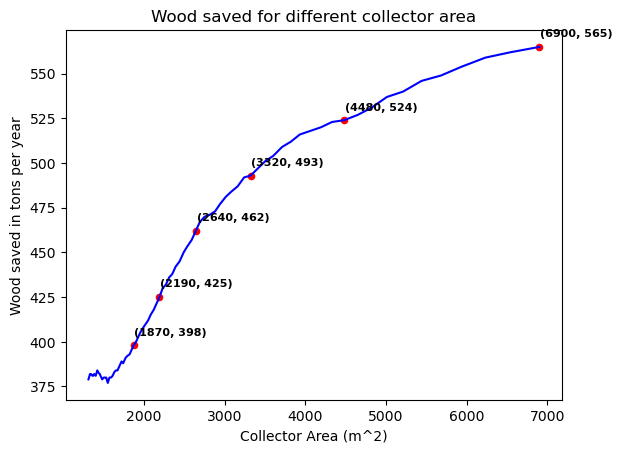

In [22]:
plt.plot(A_collector, Fuel_saved_for_different_area, color = 'blue')
plt.xlabel("Collector Area (m^2)")
plt.ylabel("Wood saved in tons per year")
plt.title('Wood saved for different collector area')
for i in range(0, len(A_collector)-20, 10):
    plt.scatter(A_collector[i], Fuel_saved_for_different_area[i],color = 'red', s= 20)
    plt.text(A_collector[i]+10, Fuel_saved_for_different_area[i]+10,
            f'{A_collector[i], Fuel_saved_for_different_area[i]}',
            fontsize=8, va='top', ha='left', fontweight='bold')
#save_fig('Wood savings')
plt.show()

### Economic analysis for 4480 m^2 area

In [23]:
Collector_cost = 4480 * 15000 #PTC cost - 15000 per m^2
Annual_savings = 524 * 3400    # Wood cost - 3000 per ton
simple_pp = Collector_cost/ Annual_savings
print(f'Collector cost:{Collector_cost}, Annual_savings:{Annual_savings}')
print(f'Simple payback period : {round(simple_pp)} years')

Collector cost:67200000, Annual_savings:1781600
Simple payback period : 38 years
